## Example 2d:
Example workflow that trains a CNN-based mixture density network to predict the amplitude and
phase aberration coefficients from a single image (not a z-stack).

Model trains itself using synthetic examples generated from the forwards model on-the-fly, with
the absolute focus position randomly jittered per example so the decoder learns to characterize
aberrations without relying on a precisely known nominal focus. Because a rigid focus shift is
physically the same pupil operator as the m=0 radial phase terms (defocus, spherical, ...), the
jitter offset is *folded into the phase labels*: the model predicts the effective aberration
actually present in the image, rather than being handed labels that contradict it.

To demonstrate the mixture's ability to represent multimodal posteriors, the nominal focus is pinned
at `z_objective = 0` so the focus jitter is symmetric about the focal plane. Symmetry about the
focal plane means the image then admits two equally-likely, symmetric solutions, which a 2-component
mixture can resolve.

Coefficient means and covariance matrices are plotted for each component in the fitted mixture.

In [1]:
import logging
import warnings

import torch
import pytorch_lightning as pl
from lightning_fabric.utilities.warnings import PossibleUserWarning
from matplotlib import pyplot

In [2]:
# Silence a few nuisance warnings:
logging.getLogger("pytorch_lightning").setLevel(logging.WARNING)
warnings.filterwarnings("ignore", category=PossibleUserWarning)
warnings.filterwarnings("ignore", message="Starting from v1.9.0, `tensorboardX`")
warnings.filterwarnings("ignore", message=r".*isinstance\(treespec, LeafSpec\).*")

In [3]:
from cynosure.config import NoiseConfig, OpticalConfig, PriorConfig, SimulationConfig, TrainingConfig, ZernikeConfig
from cynosure.utilities.training_utils import NoValidationBar
from cynosure.utilities.visualization import (
    plot_correlation_matrix,
    plot_coefficient_uncertainties,
)
from cynosure.zstack_decoding import (
    ZstackSolver_MixedDensity,
    make_object_distribution,
)

#### Simulation setup

In [4]:
# Simulation parameters:
pupil_grid_size = 255
object_grid_size = 31
object_pixel_size = 0.15  # um
rng_seed = 123

# Experimental parameters:
wavelength = 0.510  # um
focal_length = 4.50e3  # um
numerical_aperture = 0.9
medium_index = 1.54
immersion_index = 1.0
bead_diameter = 0.1  # um

# Fitting parameters:
max_phase_order = 6  # max Zernike N
max_amplitude_order = 4  # max Zernike N
z_jitter = 1.0  # um

device = "cuda" if torch.cuda.is_available() else "cpu"

In [5]:
train_cfg = TrainingConfig(
    learning_rate=1e-3,
    weight_decay=1e-3,
    batch_size=32,
    generator_chunk=4,
    steps_per_epoch=200,
    val_batches=32,
    val_seed=42,
    mixing_warmup_epochs=10,
    mixing_entropy_weight=0.5,
)
sim_cfg = SimulationConfig(
    pupil_grid_size=pupil_grid_size,
    object_grid_size=object_grid_size,
    object_pixel_size=object_pixel_size,
    ftype=torch.float32,
    ctype=torch.complex64,
)
opt_cfg = OpticalConfig(
    wavelength=wavelength,
    focal_length=focal_length,
    numerical_aperture=numerical_aperture,
    aperture_type="fitted",
    medium_index=medium_index,
    immersion_index=immersion_index,
)
phase_cfg = ZernikeConfig(
    max_phase_order,
    allowed_nm=(
        (1, 1), (1, -1),
        (2, -2), (2, 0), (2, 2),
        (3, -3), (3, -1), (3, 1), (3, 3),
        (4, -4), (4, -2), (4, 0), (4, 2), (4, 4),
        (5, -5), (5, -3), (5, -1), (5, 1), (5, 3), (5, 5),
    )
)
amp_cfg = ZernikeConfig(
    max_amplitude_order,
    allowed_nm=(
        (0, 0), (2, 0), (4, 0)
    )
)
noise_cfg = NoiseConfig(
    min_photons=100_000,
    max_photons=1_000_000,
    max_background=1_000,
    read_noise=10,
)

In [6]:
object_distrib = make_object_distribution(sim_cfg.object_grid_size, sim_cfg.object_pixel_size, bead_diameter)
phase_prior = PriorConfig(0.05, 1)
amp_prior = PriorConfig(0.05, 2)

#### Solver setup and training

In [7]:
pl.seed_everything(rng_seed, workers=True)
solver = ZstackSolver_MixedDensity(
    train_cfg=train_cfg,
    sim_cfg=sim_cfg,
    optics_cfg=opt_cfg,
    phase_cfg=phase_cfg,
    amp_cfg=amp_cfg,
    phase_prior_cfg=phase_prior,
    amp_prior_cfg=amp_prior,
    object_distribution=object_distrib,
    z_objective=torch.zeros(1),
    z_jitter=z_jitter,
    num_components=2,
    noise_cfg=noise_cfg,
    hidden_channels=(8, 8),
    embedding_dims=32,
)
solver = solver.to(device)

Seed set to 123


In [8]:
trainer = pl.Trainer(
    max_epochs=40,
    accelerator=device,
    log_every_n_steps=50,
    callbacks=[NoValidationBar()],
)
trainer.fit(solver)

Sanity Checking: |                                                                      | 0/? [00:00<?, ?it/s]

Training: |                                                                             | 0/? [00:00<?, ?it/s]

#### Sanity checking the results

In [9]:
batch_size = 8
images, phase_coefs, amp_coefs = solver.create_examples(batch_size)
pred_phase_coefs, pred_amp_coefs = solver.predict_coefficients(images)
pred_images = solver.simulate_normalized_stacks(pred_phase_coefs, pred_amp_coefs)

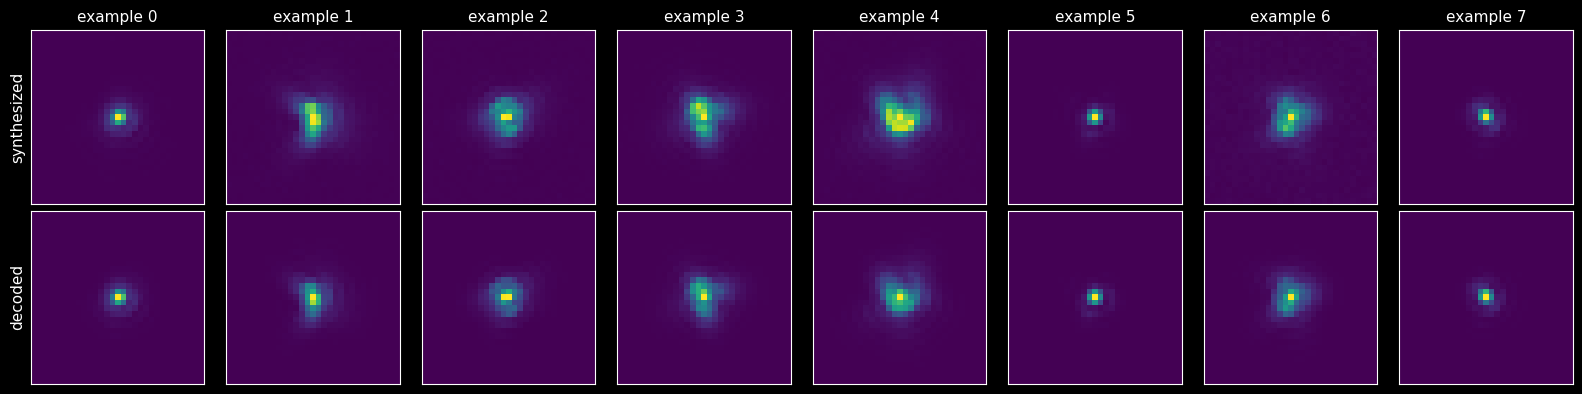

In [10]:
panel_size = 2
fig, axarr = pyplot.subplots(2, batch_size, figsize=(batch_size*panel_size, 2*panel_size))
for bidx in range(batch_size):
    ax1, ax2 = axarr[:, bidx]
    ax1.imshow(images.numpy(force=True)[bidx, 0])
    ax2.imshow(pred_images.numpy(force=True)[bidx, 0])
    ax1.set_title(f"example {bidx}", size=11)

for ax in axarr.ravel():
    ax.set_xticks([])
    ax.set_yticks([])
axarr[0, 0].set_ylabel("synthesized", size=11)
axarr[1, 0].set_ylabel("decoded", size=11)
fig.tight_layout()

#### Visualizing the predicted covariances

In [11]:
images, phase_coefs, amp_coefs = solver.create_examples(64*4)
mixture_family = solver.predict_distribution(images)
mixture = mixture_family.mixture_distribution
dist = mixture_family.component_distribution

In [12]:
kept_labels = solver.nonpiston_labels
num_kept_phase = solver.num_nonpiston_phase_coefs

covariances = dist.covariance_matrix
sigmas = covariances.diagonal(dim1=-2, dim2=-1).sqrt()
correlations = covariances / (sigmas.unsqueeze(-1) * sigmas.unsqueeze(-2))

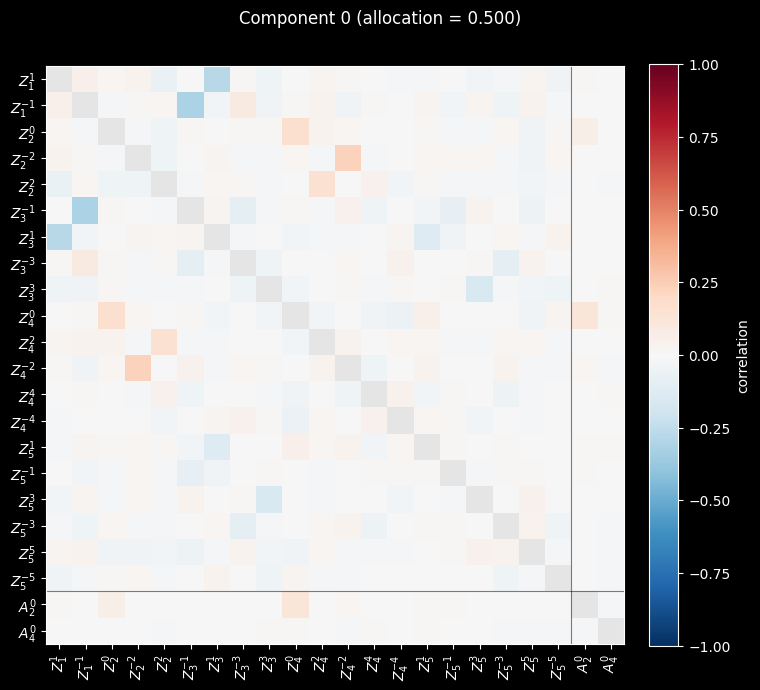

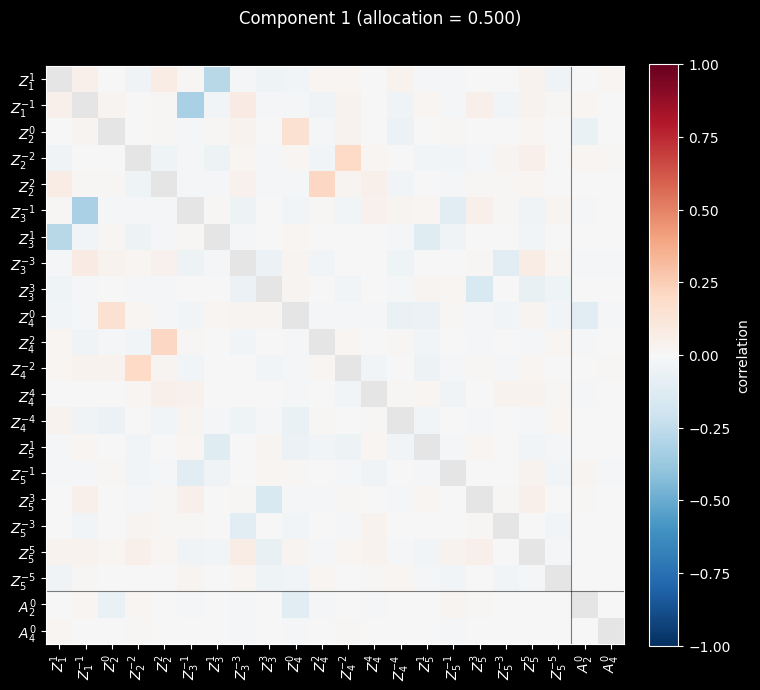

In [13]:
fig_list = [
    plot_correlation_matrix(
        correlations[:, i].mean(0).numpy(force=True),
        kept_labels,
        num_phase=num_kept_phase
    )
    for i in range(correlations.shape[1])
]
for i, (fig, alloc) in enumerate(zip(fig_list, mixture.probs.mean(0))):
    fig.suptitle(f'Component {i} (allocation = {alloc:.3f})')
    fig.tight_layout()

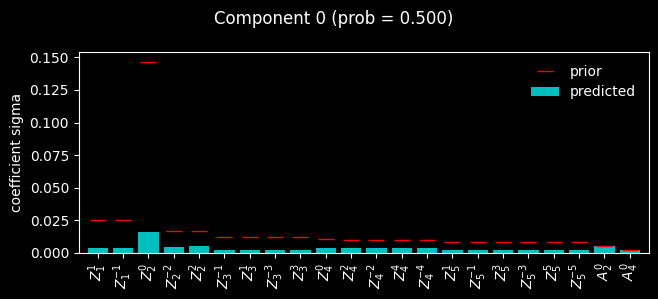

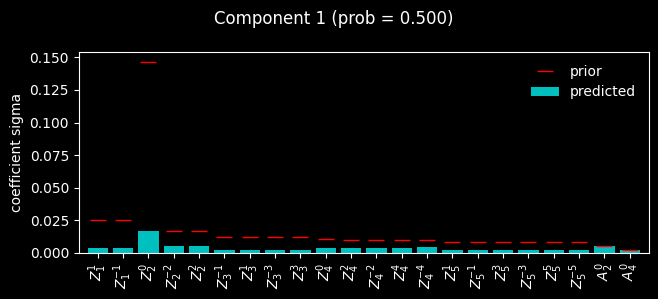

In [14]:
prior_sigmas = solver.gather_nonpiston(solver.target_scales)
fig_list = [
    plot_coefficient_uncertainties(
        sigmas[:, i].mean(0).numpy(force=True),
        prior_sigmas.numpy(force=True),
        kept_labels,
    )
    for i in range(correlations.shape[1])
]
for i, (fig, alloc) in enumerate(zip(fig_list, mixture.probs.mean(0))):
    fig.suptitle(f'Component {i} (prob = {alloc:.3f})')
    fig.tight_layout()

#### Visualizing the twin degeneracy

In [15]:
phase_is_even_n = solver.propagator.phase_projector.nm_indices[:, 0] % 2 == 0
amp_is_odd_n = solver.propagator.amp_projector.nm_indices[:, 0] % 2 == 1

def twin_coefficients(
        phase_coefs: torch.Tensor,
        amp_coefs: torch.Tensor,
) -> tuple[torch.Tensor, torch.Tensor]:
    """
    Returns the coefficients corresponding to the degenerate twin of the given ones.
    I.e., flips the signs of the even-n phases and the odd-n amplitudes.
    """
    return (
        torch.where(phase_is_even_n, -phase_coefs, phase_coefs),
        torch.where(amp_is_odd_n, -amp_coefs, amp_coefs),
    )

##### Plot images and their degenerate twins

In [16]:
images, phase_coefs, amp_coefs = solver.create_examples(256)

true_coefs = solver.gather_nonpiston(solver.join_phase_amp(phase_coefs, amp_coefs))
img_truth = solver.simulate_normalized_stacks(phase_coefs, amp_coefs)

twin_phase_coefs, twin_amp_coefs = twin_coefficients(phase_coefs, amp_coefs)
twin_coefs = solver.gather_nonpiston(solver.join_phase_amp(twin_phase_coefs, twin_amp_coefs))
img_twin = solver.simulate_normalized_stacks(twin_phase_coefs, twin_amp_coefs)

_, comp_phase_coefs, comp_amp_coefs = solver.predict_component_coefficients(images[:batch_size])
num_components = comp_phase_coefs.shape[1]
comp_images = solver.simulate_normalized_stacks(
    comp_phase_coefs.reshape(batch_size*num_components, -1),
    comp_amp_coefs.reshape(batch_size*num_components, -1),
).unflatten(0, (batch_size, num_components))  # [batch_size, num_components, num_z, H, W]

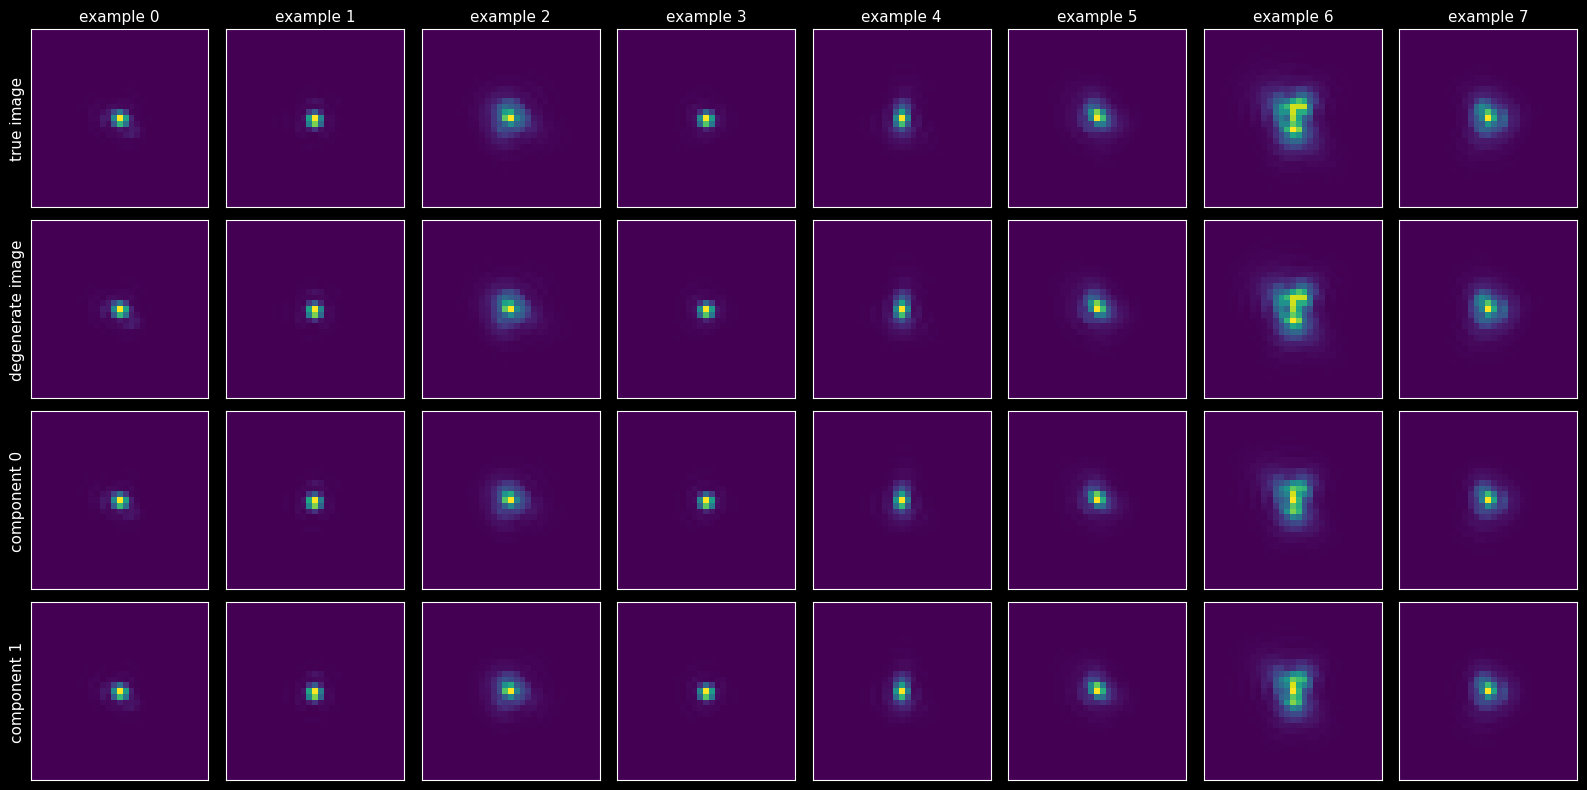

In [17]:
panel_size = 2
num_rows = 2 + num_components
figsize = (batch_size*panel_size, num_rows*panel_size)
fig, axarr = pyplot.subplots(num_rows, batch_size, figsize=figsize)
for bidx in range(batch_size):
    axarr[0, bidx].imshow(img_truth.numpy(force=True)[bidx, 0])
    axarr[1, bidx].imshow(img_twin.numpy(force=True)[bidx, 0])
    for k in range(num_components):
        axarr[2+k, bidx].imshow(comp_images.numpy(force=True)[bidx, k, 0])
    axarr[0, bidx].set_title(f"example {bidx}", size=11)

for ax in axarr.ravel():
    ax.set_xticks([])
    ax.set_yticks([])
axarr[0, 0].set_ylabel("true image", size=11)
axarr[1, 0].set_ylabel("degenerate image", size=11)
for k in range(num_components):
    axarr[2+k, 0].set_ylabel(f"component {k}", size=11)
fig.tight_layout()

##### Plot the 2D marginals along each example's two strongest twin-flipped terms

In [18]:
diff = (true_coefs - twin_coefs).abs()
dims_of_interest = diff.topk(2, dim=1).indices.sort(dim=1).values  # [B, 2] strongest twin-flipped coefs per example

mixture = solver.predict_distribution(images)
probs = mixture.mixture_distribution.probs.cpu()  # [B, K]
means = mixture.component_distribution.mean.cpu()  # [B, K, N]
covs = mixture.component_distribution.covariance_matrix.cpu()  # [B, K, N, N]

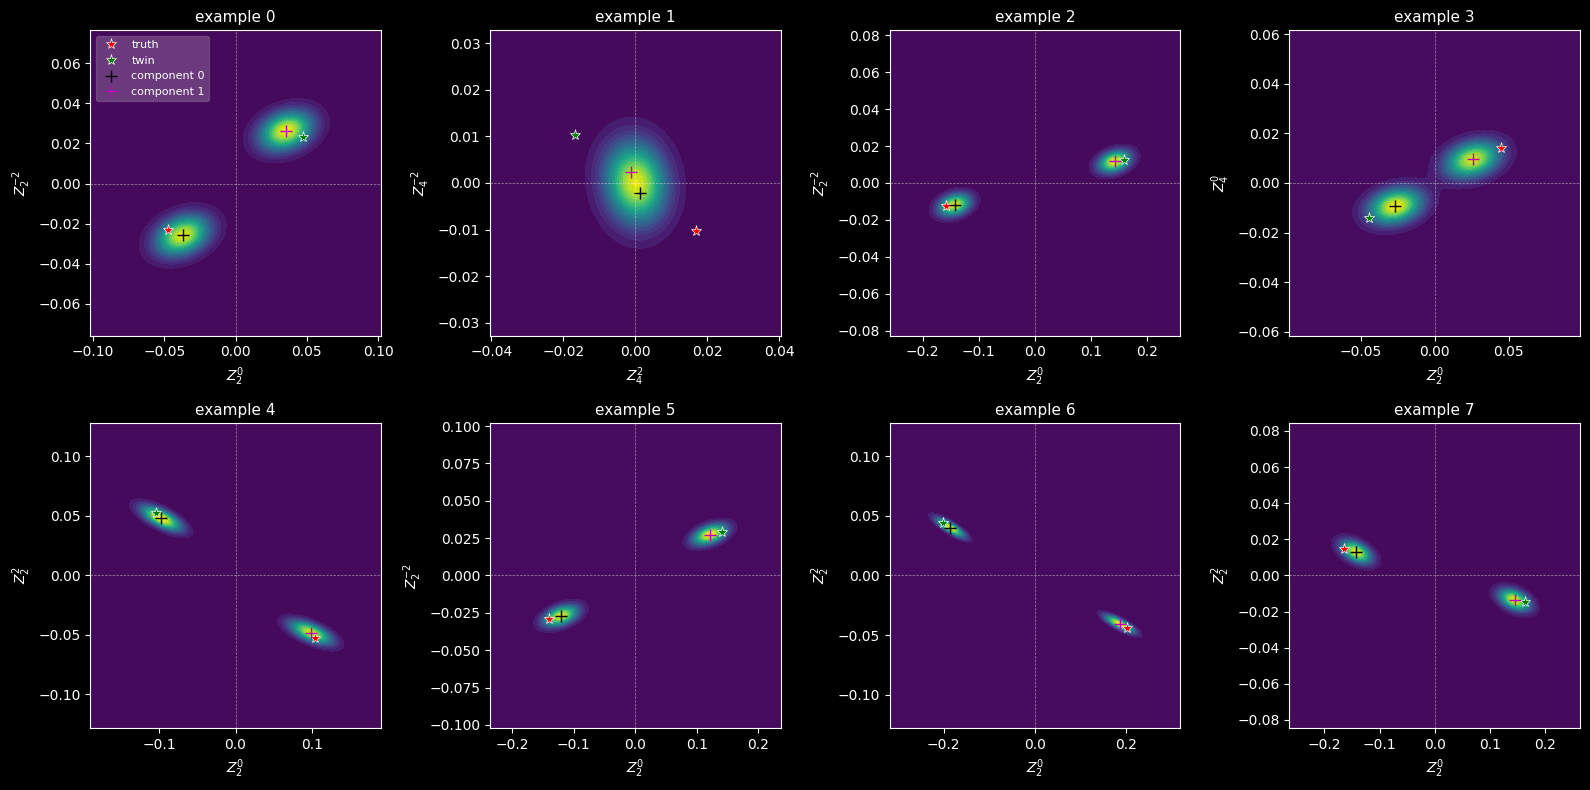

In [19]:
resolution = 201
panel_size = 4
fig, axarr = pyplot.subplots(2, batch_size//2, figsize=(batch_size//2*panel_size, panel_size*2))

for bidx, ax in enumerate(axarr.ravel()):
    dims = dims_of_interest[bidx].tolist()
    mu2 = means[bidx][:, dims]  # [K, 2]
    cov2 = covs[bidx][:, dims][:, :, dims]  # [K, 2, 2]

    anchors = torch.cat([mu2, true_coefs.cpu()[None, bidx, dims], twin_coefs.cpu()[None, bidx, dims]])
    spread = 3 * cov2.diagonal(dim1=-2, dim2=-1).sqrt().max()
    lo, hi = anchors.amin(0) - spread, anchors.amax(0) + spread

    grid_x = torch.linspace(lo[0].item(), hi[0].item(), resolution) * 1.2
    grid_y = torch.linspace(lo[1].item(), hi[1].item(), resolution) * 1.2
    mesh = torch.stack(torch.meshgrid(grid_x, grid_y, indexing="xy"), dim=-1)
    marginal = torch.distributions.MultivariateNormal(mu2, covariance_matrix=cov2)
    pdf = (probs[bidx] * marginal.log_prob(mesh.reshape(-1, 1, 2)).exp()).sum(-1).reshape(resolution, resolution)

    ax.contourf(grid_x.numpy(), grid_y.numpy(), pdf.numpy(force=True), levels=20)

    ax.plot(*true_coefs.numpy(force=True)[bidx, dims], "*", color="r", ms=8, label="truth", markeredgecolor="w", markeredgewidth=0.5)
    ax.plot(*twin_coefs.numpy(force=True)[bidx, dims], "*", color="g", ms=8, label="twin", markeredgecolor="w", markeredgewidth=0.5)

    ax.plot(*mu2.numpy(force=True)[0], "+", color="k", ms=8, label="component 0")
    ax.plot(*mu2.numpy(force=True)[1], "+", color="m", ms=8, label="component 1")

    ax.axhline(0, color="w", lw=0.5, ls="--", alpha=0.5)
    ax.axvline(0, color="w", lw=0.5, ls="--", alpha=0.5)
    ax.set_xlabel(kept_labels[dims[0]], size=10)
    ax.set_ylabel(kept_labels[dims[1]], size=10)
    ax.set_title(f"example {bidx}", size=11)

axarr[0, 0].legend(loc="upper left", fontsize=8, facecolor="w", framealpha=0.2)
fig.tight_layout()